# Téléchargement du Dataset CNN/DailyMail

Ce notebook est utilisé pour télécharger et explorer le dataset CNN/DailyMail.

In [5]:
# Cellule 1 : Vérification des fichiers
from pathlib import Path

print("=" * 60)
print("📁 VÉRIFICATION DES FICHIERS")
print("=" * 60)

data_dir = Path("data/raw")
print(f"\n📂 Dossier: {data_dir.absolute()}")

# Lister les fichiers
files = list(data_dir.glob("*.parquet"))
print(f"\n📄 Fichiers Parquet trouvés: {len(files)}")

for file in sorted(files):
    size = file.stat().st_size / (1024 * 1024)  # MB
    print(f"  ✓ {file.name:30s} : {size:>8.2f} MB")

# Vérifier le cache
cache_dir = Path("data/cache")
if cache_dir.exists():
    print(f"\n💾 Cache Hugging Face présent")
else:
    print(f"\nCache non trouvé (ce n'est pas grave)")


📁 VÉRIFICATION DES FICHIERS

📂 Dossier: C:\Users\ksenou\Desktop\LABO_DEV\IADB\projet annuel\Train-vs-Pre-train\text-summarization-comparison\notebooks\data\raw

📄 Fichiers Parquet trouvés: 5
  ✓ test-00000-of-00001.parquet    :    28.61 MB
  ✓ train-00000-of-00003.parquet   :   244.66 MB
  ✓ train-00001-of-00003.parquet   :   244.70 MB
  ✓ train-00002-of-00003.parquet   :   247.29 MB
  ✓ validation-00000-of-00001.parquet :    33.06 MB

Cache non trouvé (ce n'est pas grave)


In [8]:
# Cellule 2 : Chargement du dataset (version corrigée)
print("\n" + "=" * 60)
print("🔄 CHARGEMENT DU DATASET")
print("=" * 60)

from datasets import load_dataset

print("\n📥 Chargement depuis les fichiers Parquet...")

# Charger chaque split séparément
train_dataset = load_dataset("parquet", data_dir="data/raw", split="train")
val_dataset = load_dataset("parquet", data_dir="data/raw", split="validation")
test_dataset = load_dataset("parquet", data_dir="data/raw", split="test")

# Créer un dictionnaire pour un accès plus facile
dataset = {
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
}

print("✅ Dataset chargé avec succès !")
print(f"\n  • Train: {len(train_dataset):,} exemples")
print(f"  • Validation: {len(val_dataset):,} exemples")
print(f"  • Test: {len(test_dataset):,} exemples")



🔄 CHARGEMENT DU DATASET

📥 Chargement depuis les fichiers Parquet...
✅ Dataset chargé avec succès !

  • Train: 287,113 exemples
  • Validation: 13,368 exemples
  • Test: 11,490 exemples


In [10]:
# Cellule 3 : Informations générales
print("\n" + "=" * 60)
print(" INFORMATIONS SUR LE DATASET")
print("=" * 60)

# Splits et tailles
print("\n1. Splits disponibles :")
total = 0
for split_name in ['train', 'validation', 'test']:
    size = len(dataset[split_name])
    total += size
    print(f"  • {split_name:15s} : {size:>10,} exemples")

print(f"\n   TOTAL: {total:,} exemples (~{total/1000:.0f}k exemples)")

# Colonnes
print("\n2. Colonnes disponibles :")
print(f"  {dataset['train'].column_names}")

# Types
print("\n3. Types de données :")
for feature, dtype in dataset['train'].features.items():
    print(f"  • {feature:15s} : {dtype}")



 INFORMATIONS SUR LE DATASET

1. Splits disponibles :
  • train           :    287,113 exemples
  • validation      :     13,368 exemples
  • test            :     11,490 exemples

   TOTAL: 311,971 exemples (~312k exemples)

2. Colonnes disponibles :
  ['article', 'highlights', 'id']

3. Types de données :
  • article         : Value('string')
  • highlights      : Value('string')
  • id              : Value('string')


In [11]:
# Cellule 4 : Exemple d'article et résumé
print("\n" + "=" * 60)
print(" EXEMPLE D'ARTICLE ET SON RÉSUMÉ")
print("=" * 60)

# Premier exemple du train set
example = dataset['train'][0]

article = example['article']
summary = example['highlights']

print(f"\n ARTICLE:")
print(f"   Longueur: {len(article)} caractères | {len(article.split())} mots")
print("-" * 60)
print(article)

print(f"\n\n RÉSUMÉ:")
print(f"   Longueur: {len(summary)} caractères | {len(summary.split())} mots")
print("-" * 60)
print(summary)

print("\n" + "=" * 60)



 EXEMPLE D'ARTICLE ET SON RÉSUMÉ

 ARTICLE:
   Longueur: 2527 caractères | 455 mots
------------------------------------------------------------
LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month. "I don't think I'll be particularly extravagant. "The things I like buying are things that cost about 10 pounds -- books and CDs and DVDs." At 18, Radcliffe will be able to gamble in a casino, buy a d

In [12]:
# Cellule 5 : Statistiques détaillées
import pandas as pd

print("\n STATISTIQUES DÉTAILLÉES")
print("=" * 60)

# Échantillonner 1000 exemples pour les statistiques (plus rapide)
print("\n Calcul des statistiques sur 1000 exemples...")
train_data = []
for i in range(min(1000, len(dataset['train']))):
    example = dataset['train'][i]
    train_data.append({
        'article_length': len(example['article']),
        'summary_length': len(example['highlights']),
        'article_words': len(example['article'].split()),
        'summary_words': len(example['highlights'].split())
    })

train_df = pd.DataFrame(train_data)

print("\n1. ARTICLES:")
print(f"   • Longueur moyenne: {train_df['article_length'].mean():.0f} caractères ({train_df['article_words'].mean():.0f} mots)")
print(f"   • Longueur min: {train_df['article_length'].min():.0f} caractères")
print(f"   • Longueur max: {train_df['article_length'].max():.0f} caractères")
print(f"   • Médiane: {train_df['article_length'].median():.0f} caractères")

print("\n2. RÉSUMÉS:")
print(f"   • Longueur moyenne: {train_df['summary_length'].mean():.0f} caractères ({train_df['summary_words'].mean():.0f} mots)")
print(f"   • Longueur min: {train_df['summary_length'].min():.0f} caractères")
print(f"   • Longueur max: {train_df['summary_length'].max():.0f} caractères")
print(f"   • Médiane: {train_df['summary_length'].median():.0f} caractères")

ratio = train_df['summary_length'].mean() / train_df['article_length'].mean()
print(f"\n3. RATIO:")
print(f"   • Le résumé fait {ratio:.1%} de la longueur de l'article")



 STATISTIQUES DÉTAILLÉES

 Calcul des statistiques sur 1000 exemples...

1. ARTICLES:
   • Longueur moyenne: 3530 caractères (592 mots)
   • Longueur min: 258 caractères
   • Longueur max: 10022 caractères
   • Médiane: 3250 caractères

2. RÉSUMÉS:
   • Longueur moyenne: 252 caractères (43 mots)
   • Longueur min: 133 caractères
   • Longueur max: 372 caractères
   • Médiane: 255 caractères

3. RATIO:
   • Le résumé fait 7.1% de la longueur de l'article



 Création des visualisations...
 Graphique sauvegardé dans outputs/figures/dataset_statistics.png


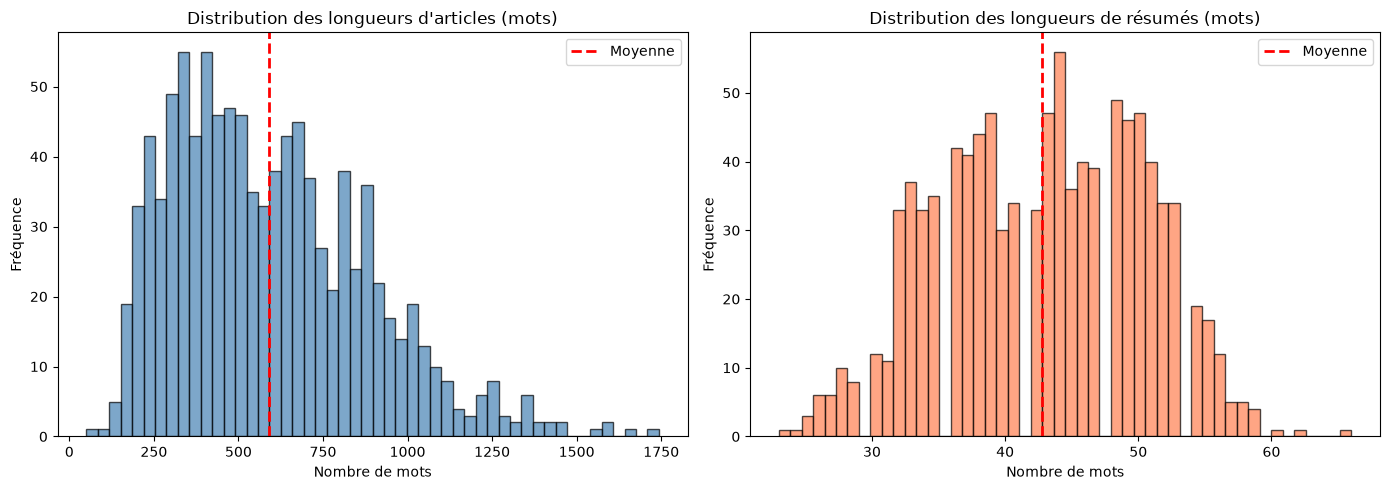

In [13]:
# Cellule 6 : Visualisation
import matplotlib.pyplot as plt

print("\n Création des visualisations...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Articles
axes[0].hist(train_df['article_words'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(train_df['article_words'].mean(), color='red', linestyle='--', linewidth=2, label='Moyenne')
axes[0].set_title('Distribution des longueurs d\'articles (mots)')
axes[0].set_xlabel('Nombre de mots')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

# Résumés
axes[1].hist(train_df['summary_words'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(train_df['summary_words'].mean(), color='red', linestyle='--', linewidth=2, label='Moyenne')
axes[1].set_title('Distribution des longueurs de résumés (mots)')
axes[1].set_xlabel('Nombre de mots')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

plt.tight_layout()

# Sauvegarder
from pathlib import Path
Path("outputs/figures").mkdir(parents=True, exist_ok=True)
plt.savefig('outputs/figures/dataset_statistics.png', dpi=300, bbox_inches='tight')
print(" Graphique sauvegardé dans outputs/figures/dataset_statistics.png")

plt.show()
